## **Detección de Ciberacoso en Redes Sociales**

Objetivo:
Desarrollar un modelo de clasificación automática que identifique si un tweet contiene contenido de ciberacoso.

Dataset:
Cyberbullying Tweets Dataset (Kaggle)

In [1]:
!pip install nltk


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Descargar diccionarios y recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\linar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\linar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\linar\AppData\Roaming\nltk_data...


True

carga de datos

In [3]:
df = pd.read_csv("cyberbullying_tweets.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,Maybe I'm reading this document wrong. http://...,religion
freq,2,7998


Análisis Exploratorio (EDA)

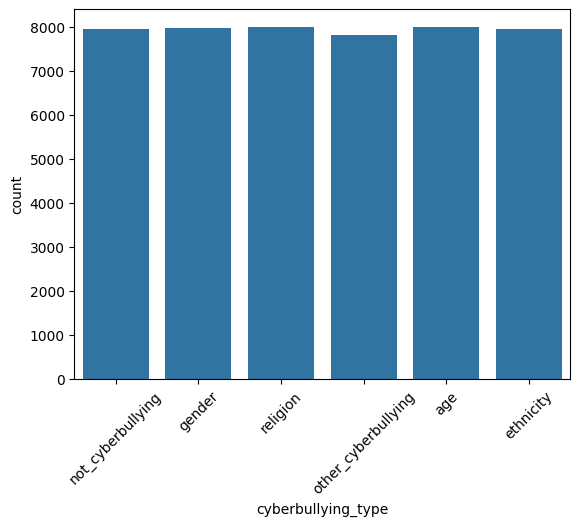

<Axes: xlabel='length', ylabel='Count'>

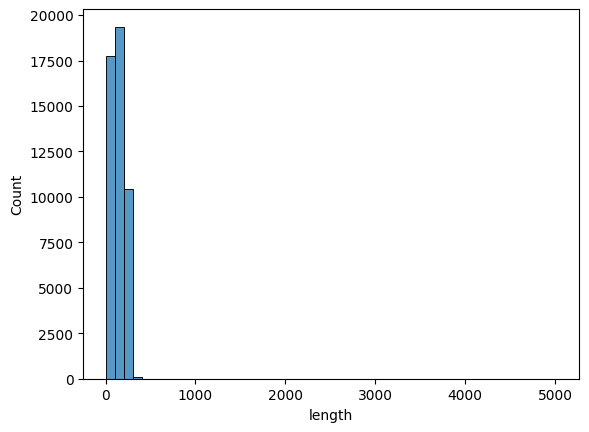

In [4]:
# Distribución de clases
sns.countplot(data=df, x="cyberbullying_type")
plt.xticks(rotation=45)
plt.show()

# Longitud de textos
df["length"] = df["tweet_text"].apply(len)
sns.histplot(df["length"], bins=50)

### **Preprocesamiento de texto (NLP Pipeline)**

**Normalización (Convertir a Minúsculas)**
Convertimos todo el texto a minúsculas para estandarizar los datos.

In [5]:
# Aseguramos que sea texto y lo pasamos a minúsculas
df["clean_text"] = df["tweet_text"].astype(str).str.lower()

df[["tweet_text", "clean_text"]].head(3)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...","in other words #katandandre, your food was cra..."
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is #aussietv so white? #mkr #theblock #ima...
2,@XochitlSuckkks a classy whore? Or more red ve...,@xochitlsuckkks a classy whore? or more red ve...


**Limpieza de Ruido**
Aquí eliminamos URLs, menciones de usuarios, hashtags, caracteres especiales y emojis.

In [6]:
def limpiar_ruido(texto):
    texto = re.sub(r"http\S+", "", texto)      # Elimina URLs
    texto = re.sub(r"@\w+", "", texto)         # Elimina menciones de usuario (@)
    texto = re.sub(r"#", "", texto)            # Elimina el símbolo de hashtag
    texto = re.sub(r"[^a-z\s]", "", texto)     # Elimina caracteres especiales y emojis
    return texto

# Aplicamos esta limpieza a la columna que ya está en minúsculas
df["clean_text"] = df["clean_text"].apply(limpiar_ruido)

df[["tweet_text", "clean_text"]].head(3)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore or more red velvet cupcakes


**Tokenización y Normalización (Stop-words)**
Separamos el texto en una lista de palabras (Tokenización) y eliminamos las palabras vacías (stop-words) que no aportan significado al modelo.

In [7]:
stop_words = set(stopwords.words('english'))

# Lambda function para separar (split) y filtrar las stop-words al mismo tiempo
df["tokens"] = df["clean_text"].apply(lambda texto: [w for w in texto.split() if w not in stop_words])

df[["clean_text", "tokens"]].head(3)

,clean_text,tokens
0,in other words katandandre your food was crapi...,"[words, katandandre, food, crapilicious, mkr]"
1,why is aussietv so white mkr theblock imaceleb...,"[aussietv, white, mkr, theblock, imacelebritya..."
2,a classy whore or more red velvet cupcakes,"[classy, whore, red, velvet, cupcakes]"


**Lematización**
Reducimos las palabras a su raíz para reducir la dimensionalidad de los datos. Luego, volvemos a unir los tokens en una sola cadena de texto para que puedan ser vectorizados.

In [8]:
lemmatizer = WordNetLemmatizer()

# Aplicamos el lematizador a cada palabra de la lista de tokens y unimos con espacios
df["clean_text"] = df["tokens"].apply(lambda lista_tokens: " ".join([lemmatizer.lemmatize(w) for w in lista_tokens]))

# Eliminamos la columna temporal de tokens para mantener el DataFrame limpio
df = df.drop(columns=["tokens"])

# Resultado final del pipeline
df[["tweet_text", "clean_text"]].head(5)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",word katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,classy whore red velvet cupcake
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh p thanks head concerned another angry dude...
4,@RudhoeEnglish This is an ISIS account pretend...,isi account pretending kurdish account like is...


### **Vectorización**

### **Fase 2: Vectorización (De Texto a Números)**

Dado que los algoritmos de Machine Learning no pueden procesar texto plano, debemos transformar nuestra columna `clean_text` en representaciones numéricas. 

Para este proyecto, implementaremos dos de los esquemas más utilizados en el procesamiento de lenguaje natural tradicional:
1.  **Bag of Words (BoW) / CountVectorizer:** Mide la frecuencia de aparición de las palabras en cada documento.
2.  **TF-IDF (Term Frequency - Inverse Document Frequency):** No solo mide la frecuencia, sino que penaliza las palabras que aparecen en demasiados documentos (como "the" o "is", aunque ya filtramos stop-words), dando más peso a los términos que son distintivos de cada categoría de ciberacoso.

Primero, realizaremos la partición del conjunto de datos en **Entrenamiento (Train)** y **Prueba (Test)** para asegurar una evaluación justa.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Definir variables X (características) y y (etiquetas)
X = df["clean_text"]
y = df["cyberbullying_type"]

# 2. Partición de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Dimensiones de Entrenamiento: {X_train.shape}")
print(f"Dimensiones de Prueba: {X_test.shape}")

Dimensiones de Entrenamiento: (38153,)
Dimensiones de Prueba: (9539,)


In [ ]:
# --- Esquema 1: Bag of Words (CountVectorizer) ---
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# --- Esquema 2: TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("¡Vectorización completada exitosamente!")
print(f"Vocabulario BoW (primeras 10 palabras): {list(bow_vectorizer.vocabulary_.keys())[:10]}")

¡Vectorización completada exitosamente!
Vocabulario BoW (primeras 10 palabras): ['fucking', 'bad', 'idea', 'say', 'terrible', 'lie', 'ally', 'see', 'rt', 'sexism']


### **Experimentación con Modelos**